In [4]:
import os

def get_class_weights(train_dir):
    class_names = sorted(os.listdir(train_dir))
    class_counts = []

    # 取得每個類別的圖數
    for cls in class_names:
        cls_path = os.path.join(train_dir, cls)
        count = len([f for f in os.listdir(cls_path) if f.endswith((".png",".jpg",".jpeg"))])
        class_counts.append(count)

    total = sum(class_counts)
    num_classes = len(class_counts)

    # 權重計算公式：資料越少權重越高
    class_weights = [total / (num_classes * c) for c in class_counts]

    print("Class counts:", dict(zip(class_names, class_counts)))
    print("Class weights:", dict(zip(class_names, class_weights)))

    return class_names, class_weights


In [7]:
import os

def get_class_weights(train_dir, class_names):
    class_counts = []

    # 依照 class_names 的順序統計
    for cls in class_names:
        cls_path = os.path.join(train_dir, cls)
        if not os.path.isdir(cls_path):
            print(f"⚠ WARNING: {cls_path} not found, count = 0")
            class_counts.append(0)
            continue

        count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".png",".jpg",".jpeg"))])
        class_counts.append(count)

    total = sum(class_counts)
    num_classes = len(class_counts)

    # 避免除以0 → 若某類別為0，給它一個很小的數
    class_counts = [c if c > 0 else 1 for c in class_counts]

    # 計算權重（資料越少權重越高）
    class_weights = [total / (num_classes * c) for c in class_counts]

    print("Class counts:", dict(zip(class_names, class_counts)))
    print("Class weights:", dict(zip(class_names, class_weights)))

    return class_weights


In [9]:
train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
class_names = [
    "Center",
    "Donut",
    "Edge-loc",
    "Edge-ring",
    "Loc",
    "Near-Full",
    "None",
    "Random",
    "Scratch"
]


weights = get_class_weights(train_dir, class_names)


Class counts: {'Center': 3916, 'Donut': 507, 'Edge-loc': 4729, 'Edge-ring': 7894, 'Loc': 2515, 'Near-Full': 104, 'None': 103201, 'Random': 606, 'Scratch': 835}
Class weights: {'Center': 3.5270400635569175, 'Donut': 27.24238439623055, 'Edge-loc': 2.9206785554850683, 'Edge-ring': 1.7496692283872421, 'Loc': 5.4918047271924015, 'Near-Full': 132.80662393162393, 'None': 0.13383483579508812, 'Random': 22.791895856252292, 'Scratch': 16.541184298070526}


In [10]:
import torch
import torch.nn as nn

weights_tensor = torch.tensor(weights, dtype=torch.float32).cuda()

criterion = nn.CrossEntropyLoss(weight=weights_tensor)


In [13]:
num_epochs = 20  # 訓練 20 個 epoch


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 範例簡單 CNN 模型
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=9):  # 假設你有 9 類
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32*16*16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 建立模型
model = SimpleCNN(num_classes=9).cuda()


In [16]:
criterion = nn.CrossEntropyLoss(weight=weights_tensor)  # ← 加權 loss

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.cuda()
        labels = labels.cuda()

        optimizer.zero_grad()

        outputs = model(images)

        # 使用加權 loss
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


NameError: name 'train_loader' is not defined

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# ===== 1️⃣ 讀取影像資料並轉成數值特徵 =====
def load_images_to_df(root_dir, class_names, img_size=(32,32)):
    data = []
    for cls in class_names:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.png','.jpg','.jpeg')):
                img_path = os.path.join(cls_path, f)
                img = Image.open(img_path).convert('L')  # 灰階
                img = img.resize(img_size)
                img_np = np.array(img).flatten()  # 1D向量
                data.append([cls] + img_np.tolist())
    columns = ['label'] + [f'px{i}' for i in range(img_size[0]*img_size[1])]
    df = pd.DataFrame(data, columns=columns)
    return df

# 設定資料夾與類別
train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
class_names = ["Center", "Donut", "Edge-loc", "Edge-ring", "Loc", "Near-Full", "None", "Random", "Scratch"]

df = load_images_to_df(train_dir, class_names)
print("Original class counts:\n", df['label'].value_counts())

X = df.drop('label', axis=1)
y = df['label']

# ===== 2️⃣ 降維 (PCA) 用於可視化 =====
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_vis = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_vis['label'] = y

# ===== 3️⃣ 平衡資料 =====
# Random Oversampling
ros = RandomOverSampler(sampling_strategy='minority', random_state=2022)
X_over, y_over = ros.fit_resample(X, y)
df_over = pd.DataFrame(X_over)
df_over['label'] = y_over

# SMOTE
smote = SMOTE(random_state=2022)
X_smote, y_smote = smote.fit_resample(X, y)
df_smote = pd.DataFrame(X_smote)
df_smote['label'] = y_smote

# Random Undersampling
rus = RandomUnderSampler(sampling_strategy='majority', random_state=2022)
X_under, y_under = rus.fit_resample(X, y)
df_under = pd.DataFrame(X_under)
df_under['label'] = y_under

# ===== 4️⃣ PCA 轉2D 可視化 =====
pca2 = PCA(n_components=2)
df_over_pca = pd.DataFrame(pca2.fit_transform(df_over.drop('label', axis=1)), columns=['PC1','PC2'])
df_over_pca['label'] = df_over['label']

df_smote_pca = pd.DataFrame(pca2.fit_transform(df_smote.drop('label', axis=1)), columns=['PC1','PC2'])
df_smote_pca['label'] = df_smote['label']

df_under_pca = pd.DataFrame(pca2.fit_transform(df_under.drop('label', axis=1)), columns=['PC1','PC2'])
df_under_pca['label'] = df_under['label']

# ===== 5️⃣ 繪圖比較 =====
fig, axs = plt.subplots(2,2,figsize=(14,12))

sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='label', ax=axs[0,0], palette='tab10')
axs[0,0].set_title("Original Imbalanced Data")

sns.scatterplot(data=df_over_pca, x='PC1', y='PC2', hue='label', ax=axs[0,1], palette='tab10')
axs[0,1].set_title("Random Oversampling")

sns.scatterplot(data=df_smote_pca, x='PC1', y='PC2', hue='label', ax=axs[1,0], palette='tab10')
axs[1,0].set_title("SMOTE Oversampling")

sns.scatterplot(data=df_under_pca, x='PC1', y='PC2', hue='label', ax=axs[1,1], palette='tab10')
axs[1,1].set_title("Random Undersampling")

plt.tight_layout()
plt.show()


ImportError: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_param_validation.py)

In [1]:
import random
import numpy as np
import pandas as pd

### 設定隨機種子，使每次產生的資料相同
random.seed(2022)

n1 = 200 # 第一類的數量(type1)
n2 = 20  # 第二類的數量(type2)

## 產生type1的data 
x = np.random.normal(0,0.5,n1)
y = np.random.normal(0,1,n1)
data1 = pd.DataFrame({'label':['type1']*n1,'x':x,'y':y})

## 產生type2的data 
x2 = np.random.normal(2,0.5,n2)
y2 = np.random.normal(2,1,n2)
data2 = pd.DataFrame({'label':['type2']*n2,'x':x2,'y':y2})

## 建立 imbalanced_data
imbalance_data = pd.concat([data1, data2])
imbalance_data['label'].value_counts()

type1    200
type2     20
Name: label, dtype: int64

In [3]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import pandas as pd

# 假設 imbalance_data 已經有 'x','y','label'
X = imbalance_data[['x', 'y']]
y = imbalance_data['label']

# Random Oversampling
oversample = RandomOverSampler(sampling_strategy='minority', random_state=2022)
X_over, y_over = oversample.fit_resample(X, y)

# 建立 DataFrame
balanced_data = pd.DataFrame(X_over, columns=['x','y'])
balanced_data['label'] = y_over  # 注意這裡用 y_over
print(Counter(balanced_data['label']))


Counter({'type1': 200, 'type2': 200})


Counter({'type1': 20, 'type2': 20})


[Text(0.5, 1.0, 'Balanced data(Under sampling)')]

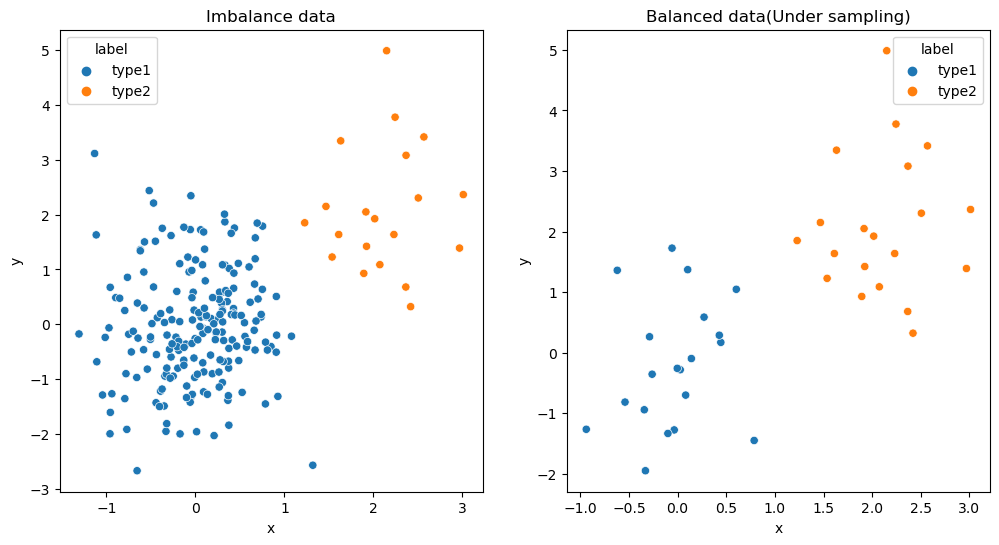

In [6]:
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

oversample = RandomUnderSampler(sampling_strategy='majority')
X_under, label = oversample.fit_resample(imbalance_data[['x','y']], imbalance_data['label'])

balanced_sample = X_under
balanced_sample['label'] = label
print(Counter(balanced_sample['label'] ))
# Counter({'type1': 20, 'type2': 20})
##繪圖
fig, axs = plt.subplots(ncols=2,figsize=(12, 6))

sns.scatterplot(data=imbalance_data, x='x', y='y', hue='label',ax=axs[0]).set(title='Imbalance data')
sns.scatterplot(data=balanced_sample, x='x', y='y', hue='label',ax=axs[1]).set(title='Balanced data(Under sampling)')

Counter({'type1': 200, 'type2': 200})


[Text(0.5, 1.0, 'Balanced data(SMOTE)')]

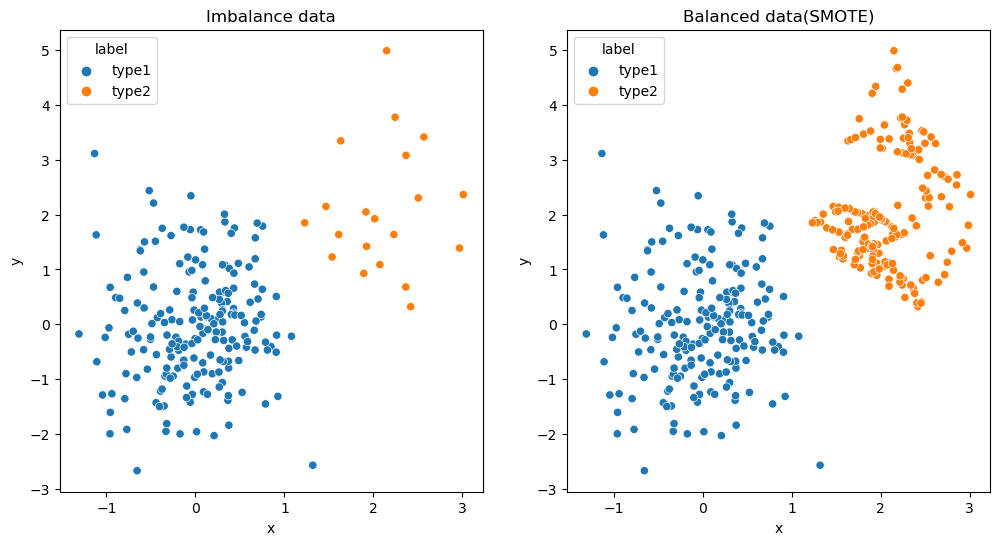

In [7]:
from imblearn.over_sampling import SMOTE

X_smote, label = SMOTE(random_state=2022).fit_resample(imbalance_data[['x','y']], imbalance_data['label'])

newData = X_smote
newData['label'] = label
print(Counter(newData['label'] ))
#Counter({'type1': 200, 'type2': 200})
##繪圖
fig, axs = plt.subplots(ncols=2,figsize=(12, 6))

sns.scatterplot(data=imbalance_data, x='x', y='y', hue='label',ax=axs[0]).set(title='Imbalance data')
sns.scatterplot(data=newData, x='x', y='y', hue='label',ax=axs[1]).set(title='Balanced data(SMOTE)')

Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.


Class Weights (by defect type):
----------------------------------------
Center       (class 0): weight = 4.476
Donut        (class 1): weight = 34.668
Edge-loc     (class 2): weight = 3.704
Edge-ring    (class 3): weight = 1.985
Loc          (class 4): weight = 5.348
Near-Full    (class 5): weight = 129.340
None         (class 6): weight = 0.130
Random       (class 7): weight = 22.197
Scratch      (class 8): weight = 16.109


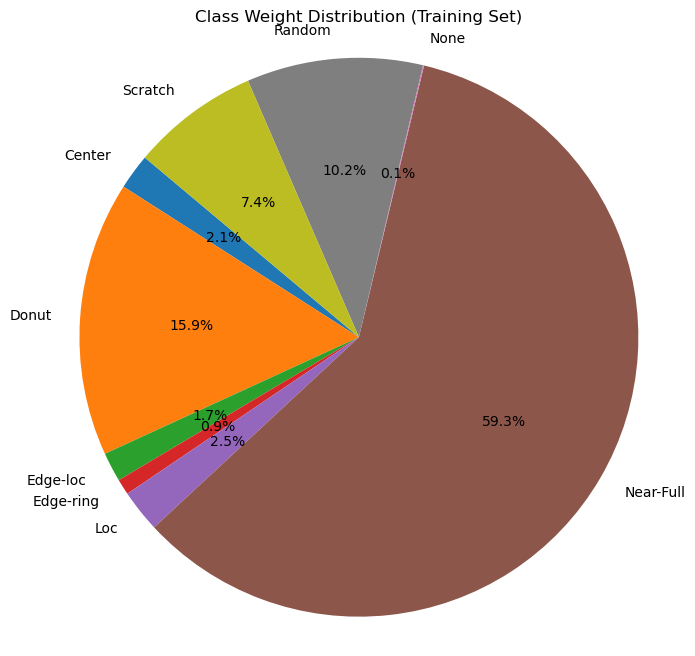

Epoch 1/5
3784/3784 [==============================] - 882s 230ms/step - loss: 2.5839 - accuracy: 0.0434 - val_loss: 2.1834 - val_accuracy: 0.0256 - lr: 0.0010
Epoch 2/5


d:\anaconda\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3784/3784 [==============================] - 749s 198ms/step - loss: 2.1991 - accuracy: 0.0417 - val_loss: 2.1936 - val_accuracy: 0.0052 - lr: 0.0010
Epoch 3/5
3784/3784 [==============================] - 691s 182ms/step - loss: 2.1992 - accuracy: 0.0480 - val_loss: 2.1936 - val_accuracy: 0.0561 - lr: 0.0010
Epoch 4/5
3784/3784 [==============================] - 599s 158ms/step - loss: 2.5325 - accuracy: 0.0999 - val_loss: 2.1628 - val_accuracy: 0.0117 - lr: 0.0010
Epoch 5/5
3784/3784 [==============================] - 445s 118ms/step - loss: 2.2751 - accuracy: 0.0548 - val_loss: 2.1862 - val_accuracy: 0.0034 - lr: 0.0010


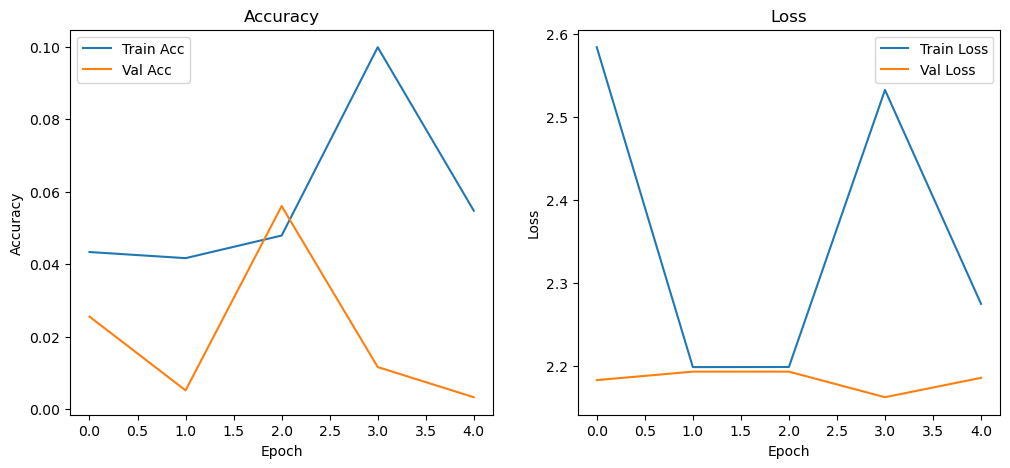

811/811 [==============================] - 34s 42ms/step


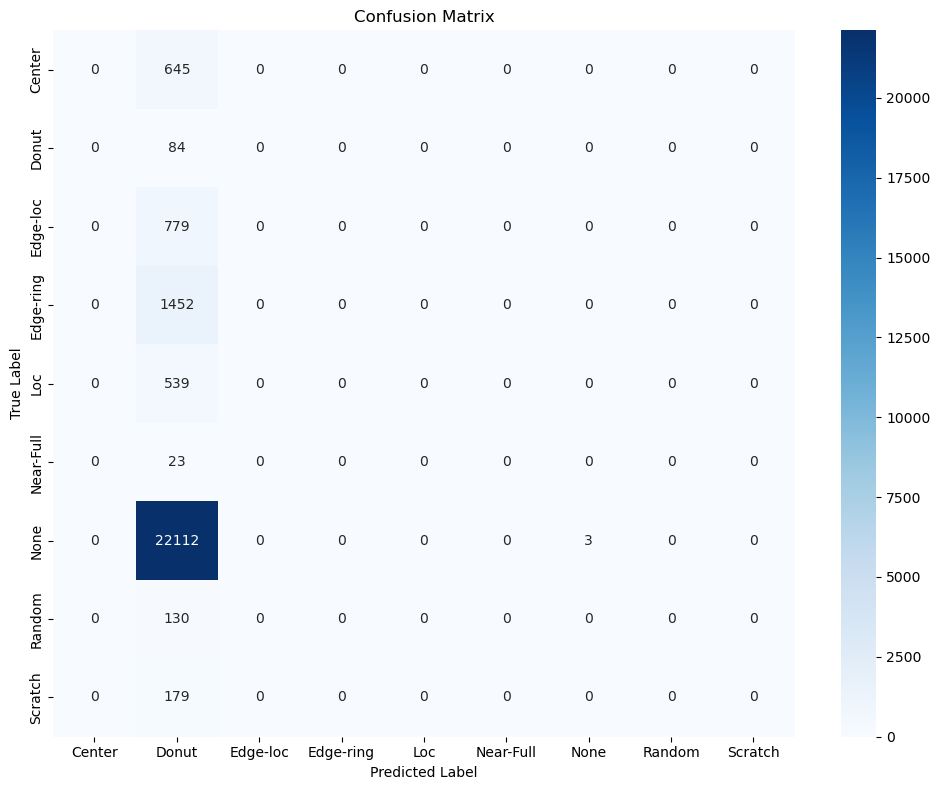

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 預測
y_true = test_set.classes
y_pred_prob = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# 類別名稱
class_names = list(test_set.class_indices.keys())

# 混淆矩陣
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [19]:
report = classification_report(y_true, y_pred, target_names=train_set.class_indices.keys())
print(report)


              precision    recall  f1-score   support

      Center       0.00      0.00      0.00       645
       Donut       0.00      1.00      0.01        84
    Edge-loc       0.00      0.00      0.00       779
   Edge-ring       0.00      0.00      0.00      1452
         Loc       0.00      0.00      0.00       539
   Near-Full       0.00      0.00      0.00        23
        None       1.00      0.00      0.00     22115
      Random       0.00      0.00      0.00       130
     Scratch       0.00      0.00      0.00       179

    accuracy                           0.00     25946
   macro avg       0.11      0.11      0.00     25946
weighted avg       0.85      0.00      0.00     25946



d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# 1. 讀取模型
model = tf.keras.models.load_model("best_model.h5")

# 2. 指定目標卷積層
target_layer = model.get_layer(index=6)  # 你最後一層 Conv2D
print("Using Grad-CAM on layer:", target_layer.name)

# 3. Grad-CAM 函式
def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val


    # heatmap 已經是 numpy ndarray 或可以直接使用
    return heatmap


# 4. 讀取影像
img_path = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\test\Center\aug_842_wafer_592197.png"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"找不到圖片: {img_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 調整大小
img_resized = cv2.resize(img, (64, 64))
img_array = np.expand_dims(img_resized / 255.0, axis=0)

# 5. 產生 heatmap
heatmap = grad_cam(model, img_array, target_layer.name)

# 6. 疊加 heatmap 到原圖
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
superimposed = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# 7. 顯示
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(superimposed)
plt.axis("off")

plt.show()
